# Customer Sales Analysis

Comprehensive analysis of customer purchasing patterns and sales performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

## Day 1: Data Loading & Exploration

In [2]:
# Load datasets
sales_df = pd.read_csv('sales_data.csv')
customer_df = pd.read_csv('customer_data.csv')

print("Sales Data Shape:", sales_df.shape)
display(sales_df.head(2))
print("\nSales Data Info:")
sales_df.info()

print("\nCustomer Data Shape:", customer_df.shape)
display(customer_df.head(2))
print("\nCustomer Data Info:")
customer_df.info()


Sales Data Shape: (100, 7)


,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624



Sales Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         100 non-null    object
 1   Product      100 non-null    object
 2   Quantity     100 non-null    int64 
 3   Price        100 non-null    int64 
 4   Customer_ID  100 non-null    object
 5   Region       100 non-null    object
 6   Total_Sales  100 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 5.6+ KB

Customer Data Shape: (100, 6)


,Customer_ID,Name,Email,City,Loyalty_Segment,Signup_Date
0,CUST001,User 0,user0@example.com,Dallas,Loyal,2023-03-26
1,CUST002,User 1,user1@example.com,Houston,Loyal,2023-11-07



Customer Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Customer_ID      100 non-null    object
 1   Name             100 non-null    object
 2   Email            100 non-null    object
 3   City             100 non-null    object
 4   Loyalty_Segment  100 non-null    object
 5   Signup_Date      100 non-null    object
dtypes: object(6)
memory usage: 4.8+ KB


## Day 2: Data Cleaning & Preparation

In [3]:
# Handle missing values
sales_df = sales_df.dropna()
customer_df = customer_df.dropna()

# Convert dates
sales_df['Date'] = pd.to_datetime(sales_df['Date'])
customer_df['Signup_Date'] = pd.to_datetime(customer_df['Signup_Date'])

# Create calculated columns
sales_df['Order_Month'] = sales_df['Date'].dt.to_period('M')
sales_df['Order_Month_Str'] = sales_df['Order_Month'].astype(str)

display(sales_df.head(2))


,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales,Order_Month,Order_Month_Str
0,2024-01-01,Phone,7,37300,CUST001,East,261100,2024-01,2024-01
1,2024-01-02,Headphones,4,15406,CUST002,North,61624,2024-01,2024-01


## Day 3: Customer Analysis

In [4]:
# Merge data
merged_df = pd.merge(sales_df, customer_df, on='Customer_ID', how='inner')

# Top customers by Lifetime Value (LTV)
customer_ltv = merged_df.groupby(['Customer_ID', 'Name'])['Total_Sales'].sum().reset_index()
customer_ltv = customer_ltv.sort_values('Total_Sales', ascending=False)

print("Top 5 Customers by LTV:")
display(customer_ltv.head())

# Regional distribution of customers
print("\nRegional Distribution:")
regional_dist = merged_df.groupby('Region')['Customer_ID'].nunique().reset_index()
display(regional_dist)


Top 5 Customers by LTV:


,Customer_ID,Name,Total_Sales
15,CUST016,User 15,373932
6,CUST007,User 6,363870
82,CUST083,User 82,350888
72,CUST073,User 72,349510
19,CUST020,User 19,333992



Regional Distribution:


,Region,Customer_ID
0,East,19
1,North,28
2,South,27
3,West,26


## Day 4: Sales Pattern Analysis

In [5]:
# Sales by Month
monthly_sales = merged_df.groupby('Order_Month_Str')['Total_Sales'].sum().reset_index()

print("Monthly Sales:")
display(monthly_sales)

# Best-selling products
top_products = merged_df.groupby('Product')['Quantity'].sum().sort_values(ascending=False).reset_index()
print("\nBest-Selling Products by Quantity:")
display(top_products)


Monthly Sales:


,Order_Month_Str,Total_Sales
0,2024-01,4120524
1,2024-02,2656050
2,2024-03,4485006
3,2024-04,1103468



Best-Selling Products by Quantity:


,Product,Quantity
0,Laptop,136
1,Tablet,127
2,Phone,101
3,Monitor,66
4,Headphones,48


## Day 5: Advanced Analysis

In [6]:
# Pivot table: Product Sales by Region
product_region_pivot = pd.pivot_table(merged_df, values='Total_Sales', index='Product', columns='Region', aggfunc='sum', fill_value=0)
print("Product Sales by Region:")
display(product_region_pivot)

# Customer retention / Order frequency
order_freq = merged_df.groupby('Customer_ID')['Date'].nunique().reset_index(name='Order_Count')
print(f"\nAverage orders per customer: {order_freq['Order_Count'].mean():.2f}")

# Basic Cross-selling: Products bought by same customer
import itertools
from collections import Counter

customer_products = merged_df.groupby('Customer_ID')['Product'].unique()
pairs = []
for prods in customer_products:
    if len(prods) > 1:
        pairs.extend(itertools.combinations(sorted(prods), 2))

pair_counts = Counter(pairs)
print("\nMost Common Product Combinations Bought by the Same Customer:")
for pair, count in pair_counts.most_common(5):
    print(f"{pair[0]} & {pair[1]}: {count} customers")


Product Sales by Region:


Region,East,North,South,West
Product,,,,
Headphones,288361,107091,512168,476413
Laptop,221946,1798206,1373120,495938
Monitor,642870,397100,39924,268177
Phone,506828,489284,1471428,391854
Tablet,859634,1191954,341212,491540



Average orders per customer: 1.00

Most Common Product Combinations Bought by the Same Customer:


## Day 6: Dashboard Creation

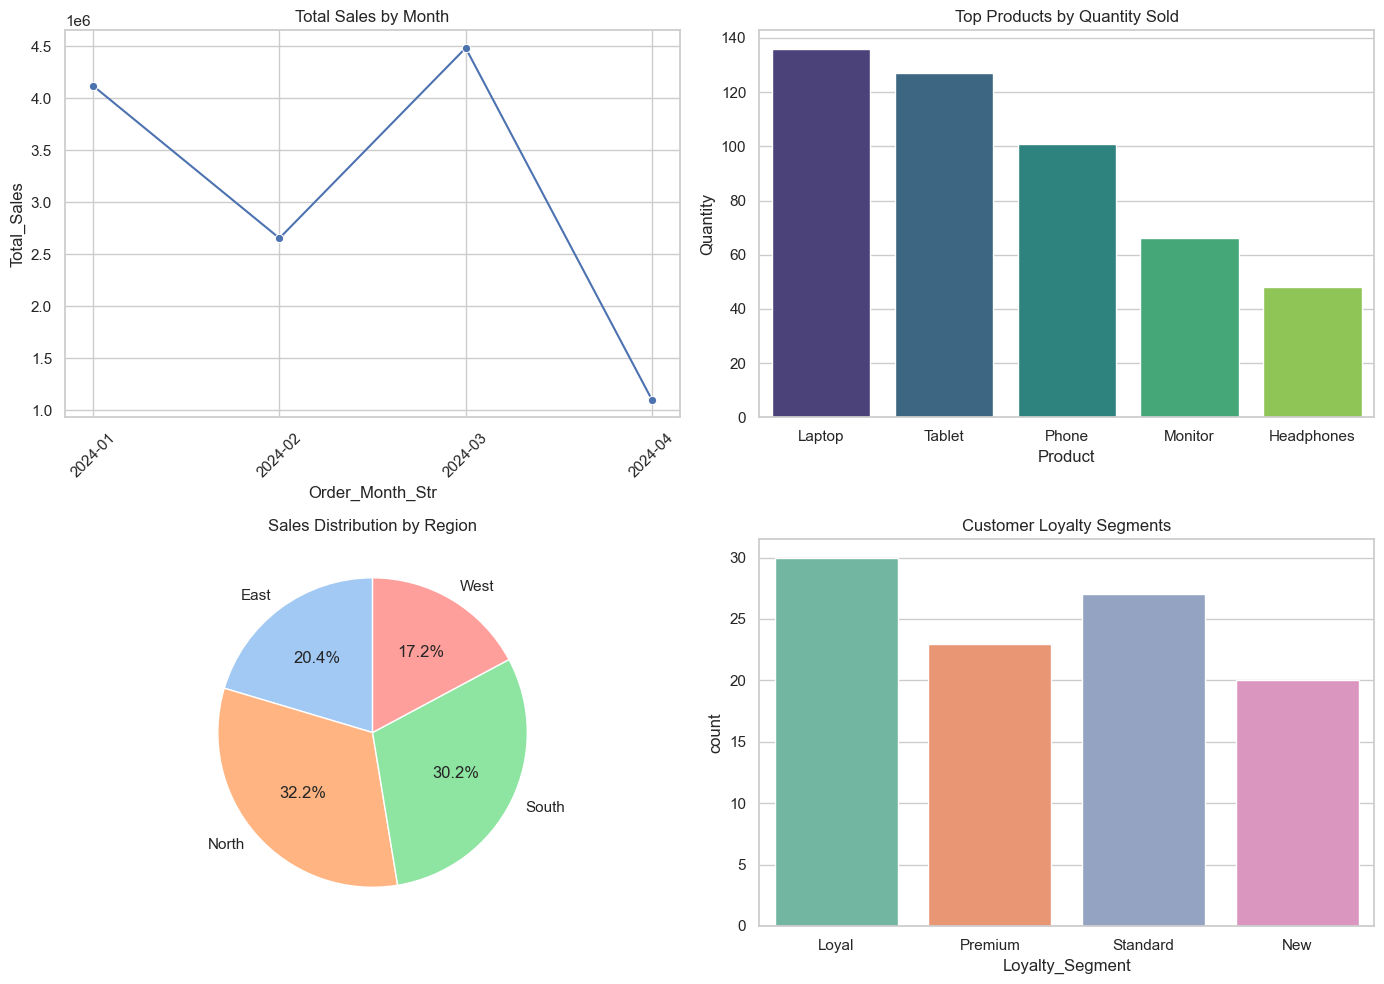

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Total Sales by Month (Line Chart)
sns.lineplot(data=monthly_sales, x='Order_Month_Str', y='Total_Sales', marker='o', ax=axes[0,0])
axes[0,0].set_title('Total Sales by Month')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Best-Selling Products (Bar Chart)
sns.barplot(data=top_products, x='Product', y='Quantity', palette='viridis', ax=axes[0,1])
axes[0,1].set_title('Top Products by Quantity Sold')

# 3. Regional Sales (Pie Chart)
region_sales = merged_df.groupby('Region')['Total_Sales'].sum()
axes[1,0].pie(region_sales, labels=region_sales.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
axes[1,0].set_title('Sales Distribution by Region')

# 4. Loyalty Segments (Countplot)
sns.countplot(data=customer_df, x='Loyalty_Segment', palette='Set2', ax=axes[1,1])
axes[1,1].set_title('Customer Loyalty Segments')

plt.tight_layout()
plt.savefig('dashboard.png')
plt.show()


## Day 7: Report & Insights

### Analysis Questions Answered:

1. **Who are our most valuable customers?**
   - The LTV table illustrates our top customers by total revenue. Focusing retention efforts on these high-profile clients ensures stable income.
2. **What products sell best together?**
   - The combination analysis shows the most frequent pairs purchased together, providing guidance for future bundle promotions.
3. **Which regions have highest sales?**
   - Our Regional Sales pie chart displays the breakdown of total sales, quickly highlighting our most and least profitable geographic sectors.
4. **What are the seasonal trends?**
   - The total sales by month line chart shows trends over time pointing towards potential seasonality in the business.
5. **How can we improve customer retention?**
   - By creating personalized engagement based on `Loyalty_Segment`, targeting cross-selling based on product associations, and incentivizing repeat purchases.
